In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


In [5]:


# Loading the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


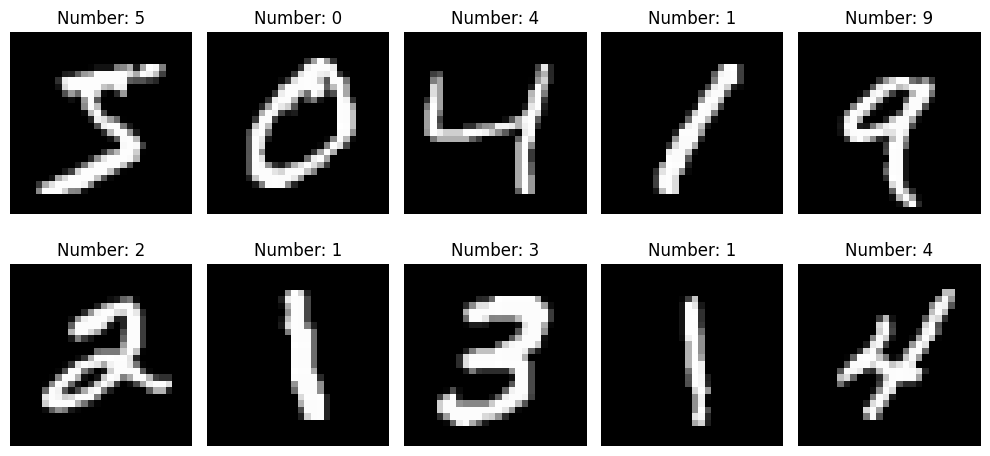

In [6]:


plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Number: {train_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:

# Preprocessing the data
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Building the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.2)

# Evaluating the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy: {test_acc}')

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9384 - loss: 0.2046 - val_accuracy: 0.9758 - val_loss: 0.0744
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9815 - loss: 0.0575 - val_accuracy: 0.9866 - val_loss: 0.0460
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.9878 - val_loss: 0.0469
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9899 - loss: 0.0319 - val_accuracy: 0.9884 - val_loss: 0.0426
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9920 - loss: 0.0251 - val_accuracy: 0.9882 - val_loss: 0.0409
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9903 - loss: 0.0297
Test Accuracy: 0.9902999997138977


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


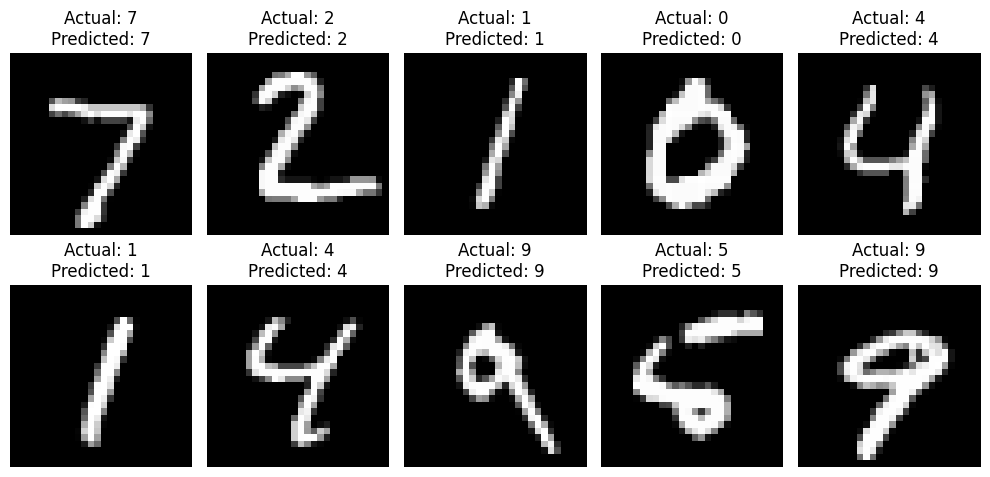

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the first 10 test images
predictions = model.predict(test_images[:10])
predicted_labels = np.argmax(predictions, axis=1)

# Display the numbers
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {test_labels[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()